In [45]:
%pip install pandas
%pip install openpyxl

#### Impoting libraies

In [46]:
import pandas as pd
import numpy as np

##### Importing data

In [47]:
df=pd.read_excel("telecom.xlsx")

#### Exploring data

In [26]:
df.head()

,Join_Date,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,2022-03-18,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,2022-02-06,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,2022-05-17,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,2020-12-02,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,2022-01-21,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [27]:
df.tail()

,Join_Date,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
7038,2021-07-24,9987-LUTYD,Female,20,No,0,La Mesa,91941,32.759327,-116.997260,...,Credit Card,55.15,742.90,0.0,0,606.84,1349.74,Stayed,NaN,NaN
7039,2020-04-09,9992-RRAMN,Male,40,Yes,0,Riverbank,95367,37.734971,-120.954271,...,Bank Withdrawal,85.10,1873.70,0.0,0,356.40,2230.10,Churned,Dissatisfaction,Product dissatisfaction
7040,2022-06-17,9992-UJOEL,Male,22,No,0,Elk,95432,39.108252,-123.645121,...,Credit Card,50.30,92.75,0.0,0,37.24,129.99,Joined,NaN,NaN
7041,2016-08-10,9993-LHIEB,Male,21,Yes,0,Solana Beach,92075,33.001813,-117.263628,...,Credit Card,67.85,4627.65,0.0,0,142.04,4769.69,Stayed,NaN,NaN
7042,2016-12-02,9995-HOTOH,Male,36,Yes,0,Sierra City,96125,39.600599,-120.636358,...,Bank Withdrawal,59.00,3707.60,0.0,0,0.00,3707.60,Stayed,NaN,NaN


In [28]:
df.shape

(7043, 39)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Join_Date                          7043 non-null   datetime64[ns]
 1   Customer ID                        7043 non-null   object        
 2   Gender                             7043 non-null   object        
 3   Age                                7043 non-null   int64         
 4   Married                            7043 non-null   object        
 5   Number of Dependents               7043 non-null   int64         
 6   City                               7043 non-null   object        
 7   Zip Code                           7043 non-null   int64         
 8   Latitude                           7043 non-null   float64       
 9   Longitude                          7043 non-null   float64       
 10  Number of Referrals                7

In [30]:
df.columns

Index(['Join_Date', 'Customer ID', 'Gender', 'Age', 'Married',
       'Number of Dependents', 'City', 'Zip Code', 'Latitude', 'Longitude',
       'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='object')

In [48]:
# Removing columns to reduce the data size
df=df.drop(columns=['Latitude','Longitude','Zip Code'])

In [32]:
df.dtypes

Join_Date                            datetime64[ns]
Customer ID                                  object
Gender                                       object
Age                                           int64
Married                                      object
Number of Dependents                          int64
City                                         object
Number of Referrals                           int64
Tenure in Months                              int64
Offer                                        object
Phone Service                                object
Avg Monthly Long Distance Charges           float64
Multiple Lines                               object
Internet Service                             object
Internet Type                                object
Avg Monthly GB Download                     float64
Online Security                              object
Online Backup                                object
Device Protection Plan                       object
Premium Tech

#### Data cleaning and transfomation

In [33]:
# Identifying is any duplicates in the data
df.duplicated().sum()

np.int64(0)

In [34]:
#Identifying any null values 
df.isnull().sum()

Join_Date                               0
Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                     1526
Streaming Music                      1526
Unlimited Data                    

In [35]:
df[[
        'Internet Type',                       
        'Avg Monthly GB Download',             
        'Online Security',                    
        'Online Backup',                      
        'Device Protection Plan',              
        'Premium Tech Support',                 
        'Streaming TV',                        
        'Streaming Movies',                    
        'Streaming Music',                     
        'Unlimited Data']]

,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data
0,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes
1,Cable,10.0,No,No,No,No,No,Yes,Yes,No
2,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes
3,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes
4,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...
7038,DSL,59.0,Yes,No,No,Yes,No,No,Yes,Yes
7039,Fiber Optic,17.0,No,No,No,No,No,Yes,Yes,Yes
7040,DSL,51.0,No,Yes,No,No,No,No,No,Yes
7041,Cable,58.0,Yes,No,Yes,Yes,No,Yes,Yes,Yes


In [49]:
no_internet=df[df['Internet Service']=='No']

In [37]:
# All the null values are because of the customer didnot using the internet service
no_internet[[
    'Internet Type',                       
        'Avg Monthly GB Download',             
        'Online Security',                    
        'Online Backup',                      
        'Device Protection Plan',              
        'Premium Tech Support',                 
        'Streaming TV',                        
        'Streaming Movies',                    
        'Streaming Music',                     
        'Unlimited Data']]

,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7028,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7033,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
# Replacing the nan values into No Internet Service
df['Avg Monthly GB Download'] = df['Avg Monthly GB Download'].fillna(0)
df['Internet Type'] = df['Internet Type'].fillna('No Internet Service')
df['Online Security'] = df['Online Security'].fillna('No Internet Service')
df['Online Backup'] = df['Online Backup'].fillna('No Internet Service')
df['Device Protection Plan'] = df['Device Protection Plan'].fillna('No Internet Service')
df['Premium Tech Support'] = df['Premium Tech Support'].fillna('No Internet Service')
df['Streaming TV'] = df['Streaming TV'].fillna('No Internet Service')
df['Streaming Movies'] = df['Streaming Movies'].fillna('No Internet Service')
df['Streaming Music'] = df['Streaming Music'].fillna('No Internet Service')
df['Unlimited Data'] = df['Unlimited Data'].fillna('No Internet Service')


In [51]:
df['Offer'].value_counts(dropna=False)

Offer
NaN        3877
Offer B     824
Offer E     805
Offer D     602
Offer A     520
Offer C     415
Name: count, dtype: int64

In [52]:
# The null values in Offer repesenting No offer
# Coverting null values to No Offer
df['Offer']=df['Offer'].fillna('No Offer')

In [53]:
no_phone=df[df['Phone Service']=='No']
no_phone['Multiple Lines']

10      NaN
14      NaN
16      NaN
19      NaN
25      NaN
       ... 
6979    NaN
6980    NaN
6996    NaN
7016    NaN
7042    NaN
Name: Multiple Lines, Length: 682, dtype: object

In [54]:
# Multiple lines null values are because the customer are not have phone service
#Rename null from multiple line to no phone service
df['Multiple Lines']=df['Multiple Lines'].fillna('No Phone Service')

In [43]:
Churn Category                       
Churn Reason  

<class 'SyntaxError'>: invalid syntax (<ipython-input-43-531f690da912>, line 1)

In [55]:
# Null values in churn reason and churn category is because the customer is not churned
# Replacing null into Not Churned to avoid nulls
df['Churn Reason']=df['Churn Reason'].fillna('Not Churned')
df['Churn Category']=df['Churn Category'].fillna('Not Churned')

In [56]:
df['Avg Monthly Long Distance Charges']=df['Avg Monthly Long Distance Charges'].fillna(0)

In [ ]:
df.isnull().sum()

In [ ]:
df.columns

In [ ]:
# To understand values inside each columns
columns = [
    'Gender', 'Age', 'Married', 'Number of Dependents', 
    'City', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service',
    'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 
    'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 
    'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
    'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
    'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 
    'Customer Status', 'Churn Category', 'Churn Reason'
]

for col in columns:
    print(pd.crosstab(df[col], df['Gender']))
    print("\n" + "="*50 + "\n")  # Adds a clean boundary between each table

In [ ]:
df['Monthly Charge']

In [57]:
# Finding monthly charge which have 0 and negative values
df[df['Monthly Charge']<=0]['Monthly Charge']

1      -4.0
32     -2.0
170    -3.0
232    -8.0
336    -1.0
       ... 
6894   -1.0
6918   -7.0
6976   -1.0
7020   -1.0
7027   -9.0
Name: Monthly Charge, Length: 120, dtype: float64

In [58]:
# Converting negative values into 0
df['Monthly Charge'] = df['Monthly Charge'].clip(lower=0)

In [ ]:
df['Monthly Charge'].value_counts()

In [59]:
# Replacing 0 into mean value  
mean_charge=df['Monthly Charge'].mean()
df['Monthly Charge']=df['Monthly Charge'].replace(0,mean_charge)

In [60]:
# Created a new column called churned
df['Churned'] = np.where(df['Churn Reason'] == 'Not Churned', 0, 1)

In [61]:
# Converting 0 and 1 into yes and no
df['Churned']=df['Churned'].replace(0,'No')
df['Churned']=df['Churned'].replace(1,'Yes')

In [ ]:
df.head()

In [62]:
min_age=df['Age'].min()
max_age=df['Age'].max()
print('min_age:',min_age)
print('max_age:',max_age)

min_age: 19
max_age: 80


In [63]:
# Creating age bins
def assign_bin(Age):
    if Age <= 25:
        return '18-25'
    elif Age <= 40:
        return '26-40'
    elif Age <= 60:
        return '41-60'
    else:
        return '60+'

In [64]:
df['Age bins']=df['Age'].apply(assign_bin)

In [ ]:
df.head()

In [65]:
min_tenure=df['Tenure in Months'].min()
max_tenure=df['Tenure in Months'].max()

print('min_tenure:',min_tenure)
print('max_tenure:',max_tenure)

min_tenure: 1
max_tenure: 72


In [66]:
#Creating tenure bins

def tenure_bins(Tenure):
    if Tenure <= 12:
        return 'One Year'
    elif Tenure <=24:
        return 'Two Year'
    elif Tenure <= 36:
        return 'Three Year'
    elif Tenure <= 48:
        return 'Four Year'
    elif Tenure <= 60 :
        return 'Five Year'
    else :
        return 'Above Five Year'

In [67]:
df['Tenure in Year']=df['Tenure in Months'].apply(tenure_bins)

In [ ]:
df.head(10)

In [ ]:
df.columns

##### Aggregations

In [68]:
# calculating total revenue
total_revenue = df['Total Revenue'].sum()
print(f'Total_revenue:',(total_revenue/1000000).round(2),'M')

Total_revenue: 21.37 M


In [69]:
# Calculate revenue lost due to churn
Revenue_lost=df[df['Customer Status']=='Churned']['Total Revenue'].sum().round(2)
print(f'Revenue_lost:',(Revenue_lost/1000000).round(2),'M')

Revenue_lost: 3.68 M


In [70]:
# Calculating total monthly charges
total_monthly_charge=df['Monthly Charge'].sum()
print(f'Total_Monthly_charge:',(total_monthly_charge/1000).round(2),'K')

Total_Monthly_charge: 456.2 K


In [71]:
# Calculate avg monthly charge
avg_monthly_charge =df['Monthly Charge'].mean()
print('avg_monthly_charge:',avg_monthly_charge.round(2))

avg_monthly_charge: 64.77


In [72]:
# Calculating total refunds
total_refund=df['Total Refunds'].sum()
print(f'Total_Refunds:',total_refund)

Total_Refunds: 13819.65


In [73]:
# Calculating total customers
total_customers=df['Customer ID'].count()
print('Total_customers:',total_customers)

Total_customers: 7043


In [74]:
# Calculating total churned customers
total_churned_customer=df[df['Customer Status']=='Churned']['Customer Status'].count()
print('Total_churned:',total_churned_customer)

Total_churned: 1869


In [75]:
# Calculating Churn rate
Churn_rate = (total_churned_customer/total_customers*100).round(2)
print(f'Churn_rate:',Churn_rate,'%')

Churn_rate: 26.54 %


In [76]:
# Calculate avg tenure period
avg_tenure =df['Tenure in Months'].mean()
print('Avg_tenure:',avg_tenure.round(2))

Avg_tenure: 32.39


##### Measures

In [77]:
# Creating a Variable called Measures to store all key calculations
measures = {
    'Total Revenue (M)': round(total_revenue / 1_000_000, 2),
    'Revenuelost_dueto_churn (M)':round(Revenue_lost/1000000,2),
    'Total Monthly Charge (K)': round(total_monthly_charge / 1_000, 2),
    'Average Monthly Charge': round(avg_monthly_charge, 2),
    'Total Refunds': total_refund,
    'Total Customers': total_customers,
    'Total Churned Customers': total_churned_customer,
    'Churn Rate (%)': round(Churn_rate, 2),
    'Average Tenure': round(avg_tenure, 2)
}

for k, v in measures.items():
    print(f"{k}: {v}")

Total Revenue (M): 21.37
Revenuelost_dueto_churn (M): 3.68
Total Monthly Charge (K): 456.2
Average Monthly Charge: 64.77
Total Refunds: 13819.65
Total Customers: 7043
Total Churned Customers: 1869
Churn Rate (%): 26.54
Average Tenure: 32.39


In [78]:
# Creating a new data frame called churn_data by filtering the details of churned customers
churn_data = df[df["Customer Status"]=='Churned']

In [79]:
# Removing some columns from churn_data (removing columns which is not neccessary for data analysis/ unwanted columns)
churn_data= churn_data.drop(columns=[
            'Avg Monthly GB Download',
           'Online Security', 'Online Backup', 'Device Protection Plan',
           'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
           'Streaming Music', 'Unlimited Data','Married'])

In [ ]:
churn_data.columns

#### IMPORTING LIBRARIES

In [80]:
%pip install seaborn matplotlib scipy

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### VISUALIZATION PARTS

##### 1) Gender wise Churn

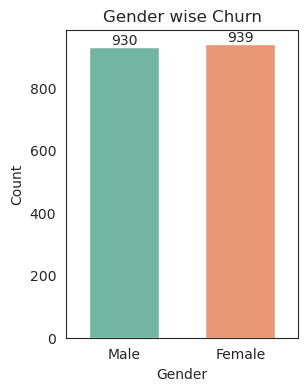

In [82]:
sns.set_style('white')
plt.figure(figsize=(3, 4))
ax = sns.countplot(x='Gender', data=churn_data,hue='Gender',palette='Set2',alpha=1,width=.6)
plt.title('Gender wise Churn')
plt.xlabel('Gender')
plt.ylabel('Count')


# Add count labels on top of bars
for i in ax.containers:
    ax.bar_label(i)

plt.show()

##### 2) Offers wise Churn

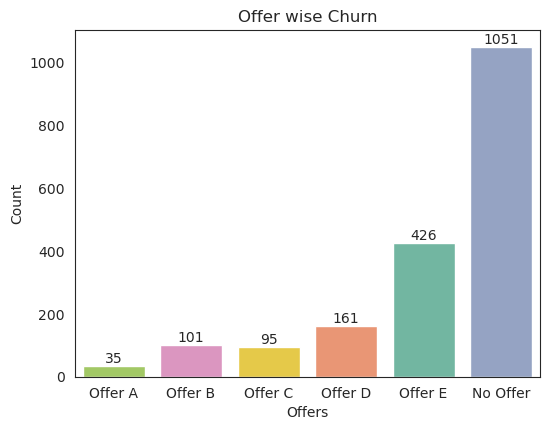

In [83]:
sns.set_style('white')
plt.figure(figsize=(6, 4.5))
ax = sns.countplot(x='Offer', data=churn_data,hue='Offer',palette='Set2',alpha=1,
                   order=['Offer A','Offer B','Offer C','Offer D','Offer E','No Offer'])
plt.title('Offer wise Churn')
plt.xlabel('Offers')
plt.ylabel('Count')

# Add count labels on top of bars
for i in ax.containers:
    ax.bar_label(i)

plt.show()

##### 3) Internet Type wise Churn

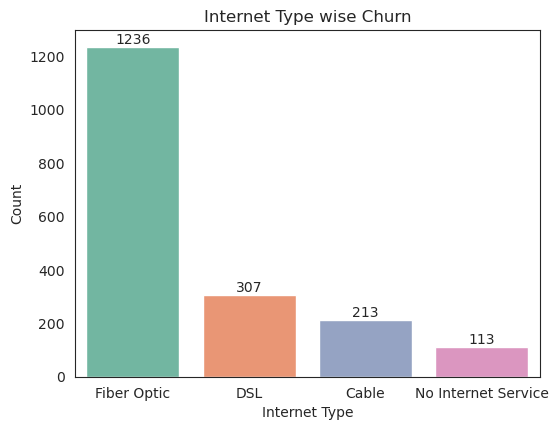

In [84]:
sns.set_style('white')
plt.figure(figsize=(6, 4.5))
ax = sns.countplot(x='Internet Type', data=churn_data,hue='Internet Type',palette='Set2',alpha=1)
plt.title('Internet Type wise Churn')
plt.xlabel('Internet Type')
plt.ylabel('Count')

# Add count labels on top of bars
for i in ax.containers:
    ax.bar_label(i)

plt.show()

##### 4) Contract wise Churn

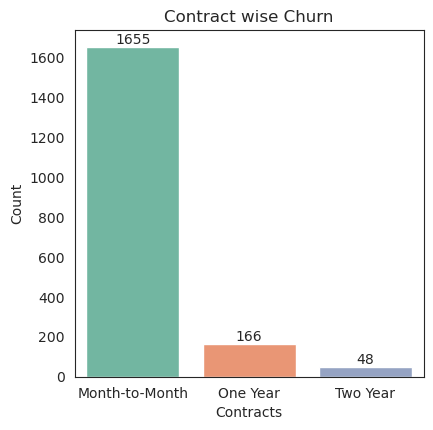

In [85]:
sns.set_style('white')
plt.figure(figsize=(4.5, 4.5))
ax = sns.countplot(x='Contract', data=churn_data,hue='Contract',palette='Set2',alpha=1)
plt.title('Contract wise Churn')
plt.xlabel('Contracts')
plt.ylabel('Count')

# Add count labels on top of bars
for i in ax.containers:
    ax.bar_label(i)

plt.show()

##### 5) Payment Method wise Churn

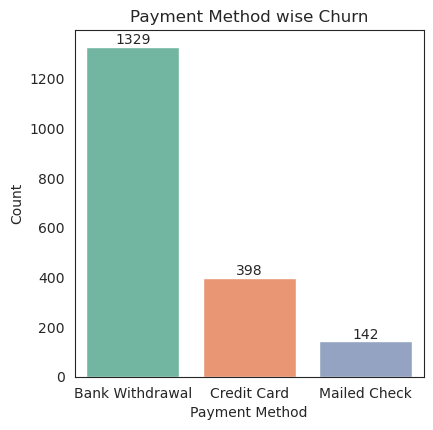

In [86]:
sns.set_style('white')
plt.figure(figsize=(4.5, 4.5))
ax = sns.countplot(x='Payment Method', data=churn_data,hue='Payment Method',palette='Set2',alpha=1)
plt.title('Payment Method wise Churn')
plt.xlabel('Payment Method')
plt.ylabel('Count')

# Add count labels on top of bars
for i in ax.containers:
    ax.bar_label(i)

plt.show()

##### 6) Churn Reasons wise Churn

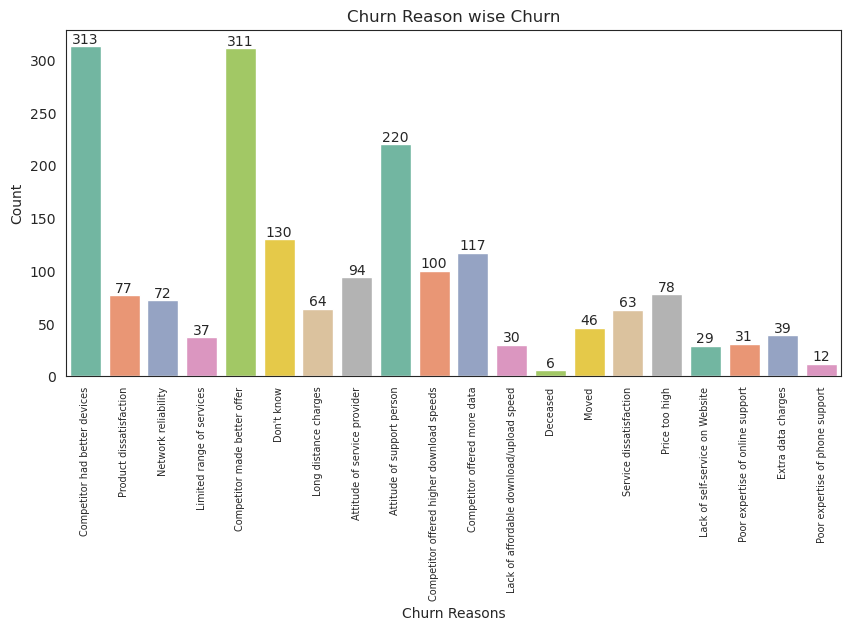

In [87]:
sns.set_style('white')
plt.figure(figsize=(10, 4.5))
ax = sns.countplot(x='Churn Reason', data=churn_data,hue='Churn Reason',palette='Set2',alpha=1)
plt.title('Churn Reason wise Churn')
plt.xlabel('Churn Reasons')
plt.ylabel('Count')
plt.xticks(rotation=90,fontsize=7)

# Add count labels on top of bars
for i in ax.containers:
    ax.bar_label(i)

plt.show()

##### 7) Churn Category wise Churn

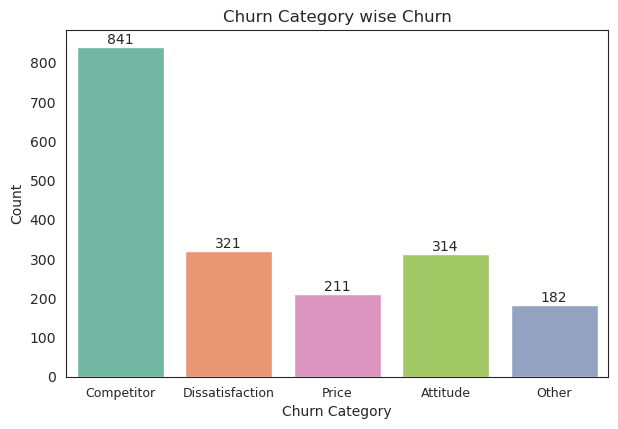

In [88]:
sns.set_style('white')
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(x='Churn Category', data=churn_data,hue='Churn Category',palette='Set2',alpha=1,
                  order=['Competitor', 'Dissatisfaction', 'Price', 'Attitude', 'Other'])
plt.title('Churn Category wise Churn')
plt.xlabel('Churn Category')
plt.ylabel('Count')
plt.xticks(fontsize=9)

# Add count labels on top of bars
for i in ax.containers:
    ax.bar_label(i)

plt.show()

##### 8) Tenure (Year) wise Churn

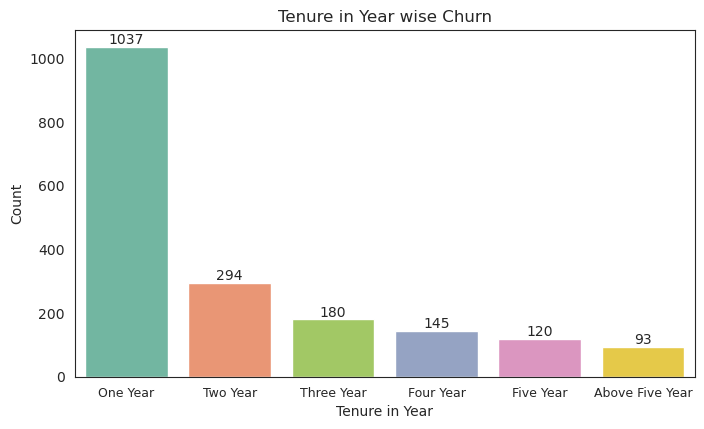

In [89]:
sns.set_style('white')
plt.figure(figsize=(8, 4.5))
ax = sns.countplot(x='Tenure in Year', data=churn_data,hue='Tenure in Year',palette='Set2',alpha=1,
                  order=['One Year','Two Year','Three Year','Four Year','Five Year','Above Five Year'])
plt.title('Tenure in Year wise Churn')
plt.xlabel('Tenure in Year')
plt.ylabel('Count')
plt.xticks(fontsize=9)

# Add count labels on top of bars
for i in ax.containers:
    ax.bar_label(i)

plt.show()

##### 9) Age bins wise Churn

In [ ]:
churn_data['Age bins'].unique()

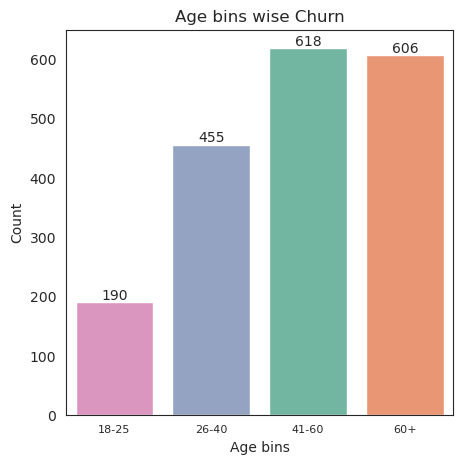

In [90]:
sns.set_style('white')
plt.figure(figsize=(5,5))
ax = sns.countplot(x='Age bins', data=churn_data,hue='Age bins',palette='Set2',alpha=1,
                  order=['18-25','26-40','41-60', '60+'])
                  
plt.title('Age bins wise Churn')
plt.xlabel('Age bins')
plt.ylabel('Count')
plt.xticks(fontsize=8)

# Add count labels on top of bars
for i in ax.containers:
    ax.bar_label(i)

plt.show()

In [ ]:
churn_data.columns

In [91]:
churn_data[['Monthly Charge', 'Total Charges','Total Revenue']]

,Monthly Charge,Total Charges,Total Revenue
2,73.900000,280.85,415.45
3,98.000000,1237.85,1599.51
4,83.900000,267.40,289.54
18,62.700000,2791.50,3271.65
19,25.100000,25.10,25.10
...,...,...,...
7020,63.688421,2030.30,2907.77
7023,83.850000,790.15,880.51
7036,70.150000,70.15,112.24
7037,20.950000,85.50,93.54


#### Pivots

In [92]:
# Revenue lost in different churn category
churn_data.pivot_table(values='Total Revenue',
                       index='Churn Category',
                       aggfunc='sum').sort_values(by='Total Revenue',ascending=False)

,Total Revenue
Churn Category,
Competitor,1694413.15
Dissatisfaction,617979.26
Attitude,579554.13
Price,438124.14
Other,354389.14


In [93]:
# Revenue lost in different churn reason (TOP 5)
churn_data.pivot_table(values='Total Revenue',
                       index='Churn Reason',
                       aggfunc='sum').sort_values(by='Total Revenue',ascending=False).nlargest(5,'Total Revenue')

,Total Revenue
Churn Reason,
Competitor made better offer,582822.20
Competitor had better devices,579877.05
Attitude of support person,404695.39
Competitor offered more data,297568.21
Don't know,256403.35


In [94]:
# Revenue lost in Contract
churn_data.pivot_table(values='Total Revenue',
                       index='Contract',
                       aggfunc='sum').sort_values(by='Total Revenue',ascending=False)

,Total Revenue
Contract,
Month-to-Month,2490105.85
One Year,858489.80
Two Year,335864.17


In [ ]:
churn_data.columns

In [95]:
# Revenue lost in Internet Type
churn_data.pivot_table(values='Total Revenue',
                       index='Internet Type',
                       aggfunc='sum').sort_values(by='Total Revenue',ascending=False)

,Total Revenue
Internet Type,
Fiber Optic,3021108.08
DSL,312450.39
Cable,307794.16
No Internet Service,43107.19


### Statstical tests

In [96]:
# Checking is there any relation between Contract type and Churns
# Creating a table for contract with churns
contract_churns=  pd.crosstab(df['Contract'],df['Churned'])
print(contract_churns)

Churned           No   Yes
Contract                  
Month-to-Month  1955  1655
One Year        1384   166
Two Year        1835    48


In [97]:
# Conducting the test
result = stats.chi2_contingency(contract_churns)

print("Chi-square:", result.statistic)
print("P-value:", result.pvalue)

if result.pvalue < 0.05:
    print('There is a statistically significant relationship between Contract Type and Customer Churn.')
else:
    print('There is no statistically significant relationship between Contract Type and Customer Churn.')

Chi-square: 1445.2932428377585
P-value: 0.0
There is a statistically significant relationship between Contract Type and Customer Churn.


In [98]:
# Checking is there any relation between Internet type  and Churns
# Creating a table for Internet type with churns
Internet_churn=df[df['Internet Type']!='No Internet Service']
internet_churn=pd.crosstab(Internet_churn['Internet Type'],Internet_churn['Churned'])
print(internet_churn)

Churned          No   Yes
Internet Type            
Cable           617   213
DSL            1345   307
Fiber Optic    1799  1236


In [99]:
# Creating test
p_value = stats.chi2_contingency(internet_churn)
print('P_value:',p_value.pvalue)

if p_value.pvalue <.05:
    print('There is a statistically significant relationship between Internet Type and Customer Churn.')
else:
    print('There is No statistically significant relationship between Internet Type and Customer Churn.')

P_value: 6.309258194179288e-57
There is a statistically significant relationship between Internet Type and Customer Churn.


In [100]:
# Checking is there any relation between Tenure(year)  and Churns
# Creating a table for Tenure(year) with churns
tenure_churn=pd.crosstab(df['Tenure in Year'],df['Churned'])
print(tenure_churn)

Churned            No   Yes
Tenure in Year             
Above Five Year  1314    93
Five Year         712   120
Four Year         617   145
One Year         1149  1037
Three Year        652   180
Two Year          730   294


In [101]:
#creating pvalue for tenure in year and churns
p_value=stats.chi2_contingency(tenure_churn)

print("P_value:",p_value.pvalue)

if p_value.pvalue < .05:
    print('There is a statistically significant relationship between Tenure and Customer Churn.')
else:
    print('There is No statistically significant relationship between Tenure and Customer Churn.')
    

P_value: 1.209674165469595e-186
There is a statistically significant relationship between Tenure and Customer Churn.


In [102]:
# Created a data frame with churn category and revenue lost on each
op=df[df['Churn Category']!='Not Churned'][['Total Revenue','Churn Category']]

In [103]:
# Revenue lost in each churn category
category_churn=op.groupby(op['Churn Category'])['Total Revenue'].sum()
print(category_churn.sort_values(ascending=False))

Churn Category
Competitor         1694413.15
Dissatisfaction     617979.26
Attitude            579554.13
Price               438124.14
Other               354389.14
Name: Total Revenue, dtype: float64


In [104]:
# Created groups for each category 
Competitor_loss=op[op['Churn Category']=='Competitor']['Total Revenue'].round(2)      
Dissatisfaction_loss=op[op['Churn Category']=='Dissatisfaction']['Total Revenue'].round(2)  
Attitude_loss=op[op['Churn Category']=='Attitude']['Total Revenue'].round(2)  
Price_loss=op[op['Churn Category']=='Price']['Total Revenue'].round(2)  
Other_loss=op[op['Churn Category']=='Other']['Total Revenue'].round(2)  

In [105]:
# Conducting ANOVA test to check is there any relationship between revenue loss with churn category
result = stats.f_oneway(
    Competitor_loss,
    Dissatisfaction_loss,
    Attitude_loss,
    Price_loss,
    Other_loss
)

print('Result:',result)
print('P_value:',result.pvalue)

if p_value.pvalue < .05:
    print('There is a statistically significant relationship between Churn Category and Revenue Lost.')
else:
    print('There is No statistically significant relationship between Churn Category and Revenue Lost.')

Result: F_onewayResult(statistic=np.float64(0.40568891888195574), pvalue=np.float64(0.8046669893511631))
P_value: 0.8046669893511631
There is a statistically significant relationship between Churn Category and Revenue Lost.


In [106]:
df.head()

,Join_Date,Customer ID,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,...,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Churned,Age bins,Tenure in Year
0,2022-03-18,0002-ORFBO,Female,37,Yes,0,Frazier Park,2,9,No Offer,...,0.00,0,381.51,974.81,Stayed,Not Churned,Not Churned,No,26-40,One Year
1,2022-02-06,0003-MKNFE,Male,46,No,0,Glendale,0,9,No Offer,...,38.33,10,96.21,610.28,Stayed,Not Churned,Not Churned,No,41-60,One Year
2,2022-05-17,0004-TLHLJ,Male,50,No,0,Costa Mesa,0,4,Offer E,...,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices,Yes,41-60,One Year
3,2020-12-02,0011-IGKFF,Male,78,Yes,0,Martinez,1,13,Offer D,...,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,Yes,60+,Two Year
4,2022-01-21,0013-EXCHZ,Female,75,Yes,0,Camarillo,3,3,No Offer,...,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability,Yes,60+,One Year


In [119]:
df.to_excel("Telecom_cleaned_data.xlsx", index=False)